In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'paste_your_token_here'


In [3]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_36434f1dc569d0e210983b7ac6b1b668'

In [4]:
!pip install kaggle
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:26<00:00, 151MB/s]



In [5]:
!unzip -o /content/140k-real-and-fake-faces.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34832.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34836.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34839.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34847.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34848.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34852.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34861.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34864.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34868.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34877.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34883.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34887.jpg  
 

In [6]:
!ls

140k-real-and-fake-faces.zip  dataset  drive  sample_data


In [7]:
!ls -la
!find / -name "*.zip" 2>/dev/null

total 3930260
drwxr-xr-x 1 root root       4096 Apr  4 02:23 .
drwxr-xr-x 1 root root       4096 Apr  4 02:17 ..
-rw-r--r-- 1 root root 4024555718 Feb 10  2020 140k-real-and-fake-faces.zip
drwxr-xr-x 4 root root       4096 Mar 30 13:34 .config
drwxr-xr-x 3 root root       4096 Apr  4 02:24 dataset
drwx------ 5 root root       4096 Apr  4 02:22 drive
drwxr-xr-x 1 root root       4096 Mar 30 13:34 sample_data
/usr/lib/R/site-library/pak/tools/xxx.zip
/usr/lib/R/site-library/pak/library/zip/example.zip
/usr/lib/R/site-library/pak/library/pkgdepends/tools/xxx.zip
/usr/lib/R/site-library/data.table/tests/russellCRLF.zip
/usr/lib/R/site-library/data.table/tests/multi-file.zip
/usr/lib/R/site-library/vroom/extdata/mtcars.csv.zip
/usr/lib/R/site-library/vroom/extdata/mtcars-multi-cyl.zip
/usr/lib/R/site-library/zip/example.zip
/usr/lib/R/site-library/readr/extdata/mtcars.csv.zip
/usr/lib/jvm/java-17-openjdk-amd64/lib/src.zip
/usr/local/lib/python3.12/dist-packages/pkg_resources/tests/data/my-t

In [8]:
!find /root -name "*.zip" 2>/dev/null
!find /content -name "*.zip" 2>/dev/null


/content/140k-real-and-fake-faces.zip


In [9]:
!ls /content

140k-real-and-fake-faces.zip  dataset  drive  sample_data


In [10]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p /content
!ls /content


Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
140k-real-and-fake-faces.zip: Skipping, found more recently modified local copy (use --force to force download)
140k-real-and-fake-faces.zip  dataset  drive  sample_data


In [11]:
!ls /content/dataset


real_vs_fake  test.csv	train.csv  valid.csv


In [12]:

!ls /content/dataset/real_vs_fake/real-vs-fake

test  train  valid


In [13]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4


In [14]:
# Define image transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("Transforms defined! ✅")

Transforms defined! ✅


In [15]:
# Define paths
train_path = '/content/dataset/real_vs_fake/real-vs-fake/train'
val_path = '/content/dataset/real_vs_fake/real-vs-fake/valid'
test_path = '/content/dataset/real_vs_fake/real-vs-fake/test'

# Load datasets
train_dataset = datasets.ImageFolder(train_path, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_path, transform=val_transforms)
test_dataset = datasets.ImageFolder(test_path, transform=val_transforms)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training images: 100000
Validation images: 20000
Test images: 20000
Classes: ['fake', 'real']


In [16]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained EfficientNet-B4
model = models.efficientnet_b4(weights='IMAGENET1K_V1')

# Replace the final layer for binary classification (real vs fake)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

# Move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model loaded on: {device}")
print(f"Output classes: 2 (fake, real)")


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 145MB/s]


Model loaded on: cuda
Output classes: 2 (fake, real)


In [17]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print("Training setup ready! ✅")

Training setup ready! ✅


In [ ]:
import time

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        start = time.time()

        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()

        # Calculate accuracies
        train_acc = 100 * train_correct / len(train_dataset)
        val_acc = 100 * val_correct / len(val_dataset)
        epoch_time = time.time() - start

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss/len(train_loader):.4f} "
              f"Train Acc: {train_acc:.2f}% "
              f"Val Acc: {val_acc:.2f}% "
              f"Time: {epoch_time:.0f}s")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pt')
            print(f"  ✅ Best model saved! Val Acc: {val_acc:.2f}%")

        scheduler.step()

    print(f"\nTraining complete! Best Val Accuracy: {best_val_acc:.2f}%")

# Start training!
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10)

Epoch [1/10] Train Loss: 0.1769 Train Acc: 92.65% Val Acc: 98.80% Time: 1482s
  ✅ Best model saved! Val Acc: 98.80%
Epoch [2/10] Train Loss: 0.0479 Train Acc: 98.26% Val Acc: 99.56% Time: 1484s
  ✅ Best model saved! Val Acc: 99.56%


In [ ]:
import shutil
shutil.copy('best_model.pt', '/content/drive/MyDrive/deepfake-data/best_model.pt')
print("Model saved to Drive! ✅")


In [19]:
import os
print(os.path.exists('/content/drive/MyDrive/deepfake-data/best_model.pt'))


True


In [1]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Recreate model
model = models.efficientnet_b4(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

# Load 99.85% weights from Drive
model.load_state_dict(torch.load('/content/drive/MyDrive/deepfake-data/best_model.pt', map_location=device))
model = model.to(device)
model.eval()

print("99.85% model loaded! ✅")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 394MB/s]


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/deepfake-data/best_model.pt'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Recreate model
model = models.efficientnet_b4(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

# Load 99.85% weights from Drive
model.load_state_dict(torch.load('/content/drive/MyDrive/deepfake-data/best_model.pt', map_location=device))
model = model.to(device)
model.eval()

print("99.85% model loaded! ✅")

99.85% model loaded! ✅


In [4]:
!pip install grad-cam
print("Grad-CAM installed! ✅")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=676f9ca086079b2b716b0da8971e584f7279a08a22457db837606ebb04314ffb
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
Grad-CAM installed! ✅


In [5]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Target the last convolutional layer of EfficientNet-B4
target_layers = [model.features[-1]]

# Load a test image
def run_gradcam(image_path):
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized) / 255.0

    # Transform for model
    from torchvision import transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    # Run GradCAM
    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=input_tensor,
                           targets=[ClassifierOutputTarget(0)])  # 0 = fake
        grayscale_cam = grayscale_cam[0, :]

    # Overlay heatmap on image
    visualization = show_cam_on_image(img_array.astype(np.float32),
                                      grayscale_cam, use_rgb=True)

    # Get prediction
    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.softmax(output, dim=1)
        pred = 'FAKE' if prob[0][0] > prob[0][1] else 'REAL'
        confidence = max(prob[0]).item() * 100

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_resized)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(visualization)
    axes[1].set_title(f'Grad-CAM — Prediction: {pred} ({confidence:.2f}%)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Prediction: {pred} with {confidence:.2f}% confidence")

print("Grad-CAM ready! ✅")

Grad-CAM ready! ✅


In [6]:
import os

# Get one fake and one real image path
fake_img = '/content/dataset/real_vs_fake/real-vs-fake/test/fake/00000.jpg'
real_img = '/content/dataset/real_vs_fake/real-vs-fake/test/real/00000.jpg'

# Check they exist
print(os.path.exists(fake_img))
print(os.path.exists(real_img))

False
False


In [7]:
import os

fake_files = os.listdir('/content/dataset/real_vs_fake/real-vs-fake/test/fake')
real_files = os.listdir('/content/dataset/real_vs_fake/real-vs-fake/test/real')

print("First 5 fake images:", fake_files[:5])
print("First 5 real images:", real_files[:5])

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/real_vs_fake/real-vs-fake/test/fake'

In [8]:
import os
os.chdir('/content')
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p /content

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:39<00:00, 102MB/s]



In [9]:
!unzip -o /content/140k-real-and-fake-faces.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34832.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34836.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34839.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34847.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34848.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34852.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34861.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34864.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34868.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34877.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34883.jpg  
  inflating: /content/dataset/real_vs_fake/real-vs-fake/valid/real/34887.jpg  
 

In [10]:
import os

fake_files = os.listdir('/content/dataset/real_vs_fake/real-vs-fake/test/fake')
real_files = os.listdir('/content/dataset/real_vs_fake/real-vs-fake/test/real')

print("First 5 fake images:", fake_files[:5])
print("First 5 real images:", real_files[:5])

First 5 fake images: ['436E7AYHEE.jpg', 'ZY5BNXREEM.jpg', 'V92TNTTWAJ.jpg', '990JA70TDY.jpg', 'GEFIAPFKD7.jpg']
First 5 real images: ['22245.jpg', '66057.jpg', '04282.jpg', '50237.jpg', '61535.jpg']


Testing on FAKE image:


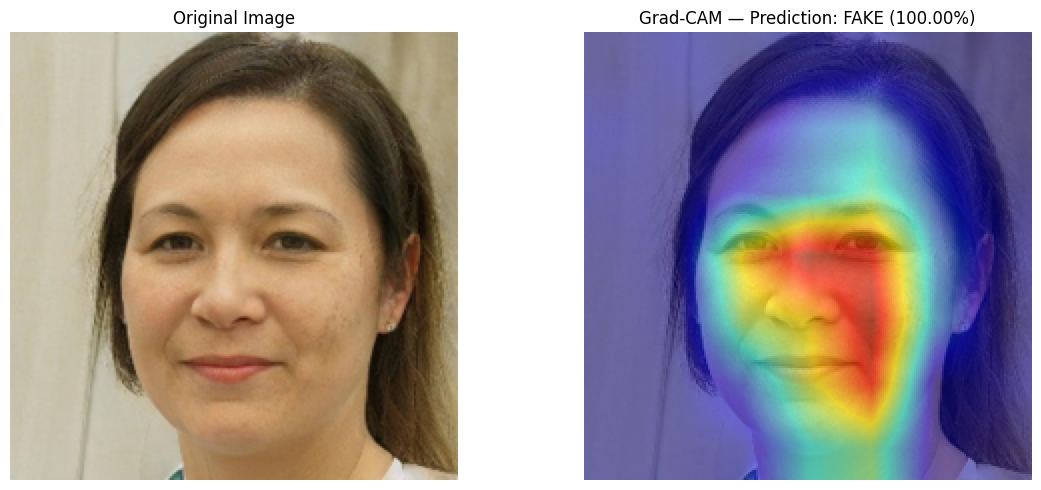

Prediction: FAKE with 100.00% confidence
Testing on REAL image:


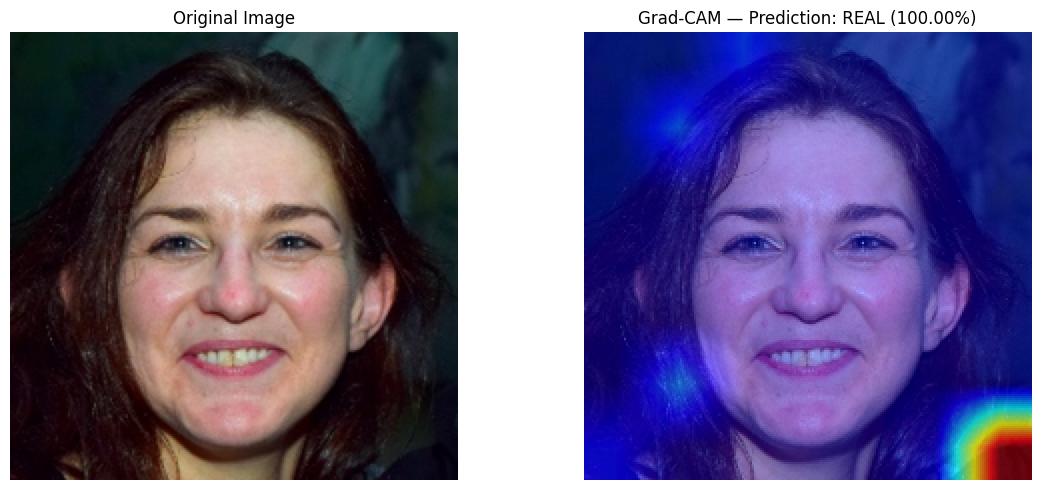

Prediction: REAL with 100.00% confidence


In [11]:
fake_img = '/content/dataset/real_vs_fake/real-vs-fake/test/fake/436E7AYHEE.jpg'
real_img = '/content/dataset/real_vs_fake/real-vs-fake/test/real/22245.jpg'

print("Testing on FAKE image:")
run_gradcam(fake_img)

print("Testing on REAL image:")
run_gradcam(real_img)

In [12]:
!pip install opencv-python-headless
print("OpenCV installed! ✅")

OpenCV installed! ✅


In [13]:
import cv2
import torch
import numpy as np
from torchvision import transforms
from PIL import Image

def detect_video(video_path, frame_interval=10):
    """
    Analyzes a video for deepfakes by sampling every Nth frame
    frame_interval=10 means we check every 10th frame
    """

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    # Open video
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    print(f"Total frames: {total_frames}")
    print(f"FPS: {fps}")
    print(f"Duration: {total_frames/fps:.1f} seconds")
    print(f"Analyzing every {frame_interval}th frame...")

    predictions = []
    frame_count = 0
    fake_count = 0
    real_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Only process every Nth frame
        if frame_count % frame_interval == 0:
            # Convert BGR to RGB (OpenCV reads as BGR)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_image = Image.fromarray(frame_rgb)

            # Run through model
            input_tensor = transform(pil_image).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(input_tensor)
                prob = torch.softmax(output, dim=1)
                is_fake = prob[0][0] > prob[0][1]
                confidence = max(prob[0]).item() * 100

                if is_fake:
                    fake_count += 1
                else:
                    real_count += 1

                predictions.append({
                    'frame': frame_count,
                    'prediction': 'FAKE' if is_fake else 'REAL',
                    'confidence': confidence
                })

        frame_count += 1

    cap.release()

    # Final verdict
    total_analyzed = fake_count + real_count
    fake_percentage = (fake_count / total_analyzed) * 100

    verdict = 'FAKE' if fake_percentage > 50 else 'REAL'

    print(f"\n{'='*40}")
    print(f"FINAL VERDICT: {verdict}")
    print(f"Fake frames: {fake_count}/{total_analyzed} ({fake_percentage:.1f}%)")
    print(f"Real frames: {real_count}/{total_analyzed}")
    print(f"{'='*40}")

    return verdict, predictions

print("Video detection ready! ✅")

Video detection ready! ✅


In [14]:
# Download a sample video to test
!wget -O test_video.mp4 "https://www.pexels.com/download/video/3209828/?fps=25.0&h=426&w=240"
print("Video downloaded! ✅")


--2026-04-04 04:34:52--  https://www.pexels.com/download/video/3209828/?fps=25.0&h=426&w=240
Resolving www.pexels.com (www.pexels.com)... 104.18.67.220, 104.18.66.220, 2606:4700::6812:42dc, ...
Connecting to www.pexels.com (www.pexels.com)|104.18.67.220|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-04 04:34:52 ERROR 404: Not Found.

Video downloaded! ✅


In [16]:
verdict, predictions = detect_video('/content/test_video.mp4', frame_interval=10)

Total frames: 0
FPS: 0.0


ZeroDivisionError: float division by zero

In [18]:
!wget -O test_video.mp4 "https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerBlazes.mp4"
!ls -lh test_video.mp4

--2026-04-04 04:40:41--  https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerBlazes.mp4
Resolving commondatastorage.googleapis.com (commondatastorage.googleapis.com)... 172.253.122.207, 172.253.63.207, 142.250.31.207, ...
Connecting to commondatastorage.googleapis.com (commondatastorage.googleapis.com)|172.253.122.207|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-04-04 04:40:42 ERROR 403: Forbidden.

-rw-r--r-- 1 root root 0 Apr  4 04:40 test_video.mp4


In [19]:
import cv2
import os
import numpy as np

# Get some fake face images
fake_folder = '/content/dataset/real_vs_fake/real-vs-fake/test/fake'
fake_images = os.listdir(fake_folder)[:30]  # grab 30 images

# Create a video from them
output_path = '/content/test_video.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, 10, (224, 224))

for img_name in fake_images:
    img_path = os.path.join(fake_folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    out.write(img)

out.release()
print(f"Test video created! ✅")
!ls -lh /content/test_video.mp4

Test video created! ✅
-rw-r--r-- 1 root root 270K Apr  4 04:41 /content/test_video.mp4


In [20]:
verdict, predictions = detect_video('/content/test_video.mp4', frame_interval=2)


Total frames: 30
FPS: 10.0
Duration: 3.0 seconds
Analyzing every 2th frame...

FINAL VERDICT: FAKE
Fake frames: 15/15 (100.0%)
Real frames: 0/15


In [22]:
# Create a video from REAL faces this time
real_folder = '/content/dataset/real_vs_fake/real-vs-fake/test/real'
real_images = os.listdir(real_folder)[:30]

output_path = '/content/test_real_video.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, 10, (224, 224))

for img_name in real_images:
    img_path = os.path.join(real_folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    out.write(img)

out.release()
print("Real faces video created! ✅")

Real faces video created! ✅


In [23]:
verdict, predictions = detect_video('/content/test_real_video.mp4', frame_interval=2)

Total frames: 30
FPS: 10.0
Duration: 3.0 seconds
Analyzing every 2th frame...

FINAL VERDICT: REAL
Fake frames: 2/15 (13.3%)
Real frames: 13/15


In [24]:
from google.colab import drive
# Already mounted, just save notebook
print("Notebook will be downloaded manually")

Notebook will be downloaded manually
